# 05 — CNN + BatchNorm + Dropout + Learning Rate Scheduling on CIFAR-10

**Project:** Progressive CNN Classifier Study
**Stage:** 5 of 6 — Adding Learning Rate Scheduling

### Goal
Build on Notebook 03 (BatchNorm + Dropout, still your best result at 0.7250 accuracy) — **not** the augmentation branch, since that plateaued lower. Add a **Learning Rate Schedule** so the optimizer takes large steps early (fast progress) and progressively smaller, more precise steps later (fine-tuning near the optimum).

### Scoreboard so far
| Notebook | Technique | Epochs | Test Accuracy | Test Loss |
|---|---|---|---|---|
| 01 | Baseline | 15 | 0.7166 | 0.8821 |
| 02 | + BatchNorm | 15 | 0.6807 | 1.5024 |
| 03 | + BatchNorm + Dropout | 15 | 0.7250 | 0.7805 |
| 04 | + Data Augmentation | 15 | 0.6359 | 1.0204 |
| 04b | + Data Augmentation | 35 | 0.6680 | 0.9441 |
| 05 (this one) | 03 + LR Scheduling | 15 | *TBD* | *TBD* |

### What is Learning Rate Scheduling?
With a fixed learning rate (what we've used so far — Adam's default), the optimizer takes the same-sized steps throughout training. This is often suboptimal:
- **Early in training:** far from the optimum, large steps make sense (fast progress).
- **Late in training:** close to the optimum, large steps cause overshooting/oscillation instead of settling precisely.

A schedule reduces the learning rate over time, giving both benefits. We'll use `ReduceLROnPlateau`: instead of a fixed schedule (like halving every N epochs regardless of progress), it watches validation loss and only reduces the learning rate when improvement stalls — an adaptive, data-driven approach.

### What this notebook covers
- Adding a `ReduceLROnPlateau` callback
- Tracking the learning rate over training to see when/how often it changes
- Comparing convergence speed and final accuracy against Notebook 03

## 1. Imports

In [1]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import cifar10
import matplotlib.pyplot as plt

print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.21.0
GPU available: []


## 2. Load and Preprocess CIFAR-10

In [2]:
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ["airplane", "automobile", "bird", "cat", "deer",
               "dog", "frog", "horse", "ship", "truck"]

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 3. Build the Model

Same architecture as Notebook 03 (BatchNorm + Dropout). No augmentation layer here — we're isolating LR scheduling as the only new variable on top of our best-performing setup so far.

In [3]:
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation="relu", input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.BatchNormalization(),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(64, activation="relu"),
    layers.Dropout(0.5),
    layers.Dense(10, activation="softmax")
])

model.summary()

/Users/adityagupta/Desktop/Machine learning/GDenv/lib/python3.11/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 30, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 13, 13, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 123,210 (481.29 KB)

 Trainable params: 122,890 (480.04 KB)

 Non-trainable params: 320 (1.25 KB)

## 4. Compile

Same optimizer, loss, and metric as before. The learning rate itself will be controlled by a callback during `fit()`, not set here.

In [4]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

## 5. Set Up the Learning Rate Scheduler

`ReduceLROnPlateau` parameters:
- `monitor="val_loss"` — watches validation loss (a more sensitive/earlier overfitting signal than accuracy).
- `factor=0.5` — when triggered, the learning rate is halved.
- `patience=3` — waits 3 epochs of no improvement before reducing (avoids overreacting to normal noise).
- `min_lr=1e-6` — floor so the learning rate never becomes too small to make progress.
- `verbose=1` — prints a message whenever the learning rate actually changes, so we can see exactly when it kicked in.

In [5]:
lr_scheduler = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

## 6. Train with the Scheduler

Same 15 epochs, batch size 64 as Notebook 03 — only the callback is new, so any difference is attributable to LR scheduling alone.

In [6]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    batch_size=64,
    validation_data=(x_test, y_test),
    callbacks=[lr_scheduler]
)

Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - accuracy: 0.3592 - loss: 1.8717 - val_accuracy: 0.4325 - val_loss: 1.5521 - learning_rate: 0.0010
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.4828 - loss: 1.4407 - val_accuracy: 0.4406 - val_loss: 1.5354 - learning_rate: 0.0010
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.5381 - loss: 1.2943 - val_accuracy: 0.5888 - val_loss: 1.1531 - learning_rate: 0.0010
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.5737 - loss: 1.2075 - val_accuracy: 0.5756 - val_loss: 1.2318 - learning_rate: 0.0010
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6014 - loss: 1.1333 - val_accuracy: 0.6280 - val_loss: 1.0765 - learning_rate: 0.0010
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6189 - loss: 1.0877 - val_accuracy: 0.6573 - val_loss: 0.9633 - learning_rate: 0.0010
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 10s 13ms/step - accuracy: 0.6353 - l

## 7. Save the Model

In [7]:
os.makedirs("models", exist_ok=True)
os.makedirs("results", exist_ok=True)

model.save("models/lr_scheduling_cnn.h5")
print("Model saved to models/lr_scheduling_cnn.h5")

Model saved to models/lr_scheduling_cnn.h5


## 8. Visualize Training Curves

Compare against Notebook 03. Look for: does loss keep decreasing more smoothly/consistently in later epochs, especially right after each LR drop (visible in the printed "ReduceLROnPlateau reducing learning rate" messages above)?

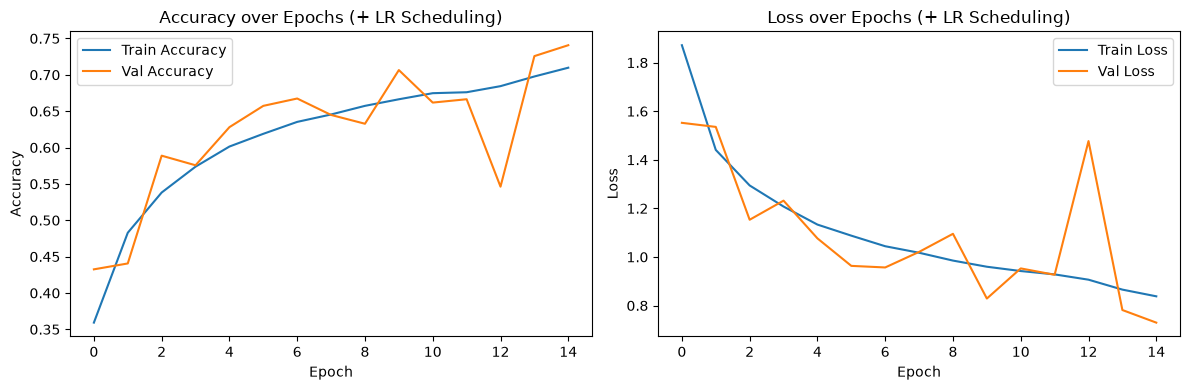

In [8]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy over Epochs (+ LR Scheduling)")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Val Loss")
plt.title("Loss over Epochs (+ LR Scheduling)")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.savefig("results/lr_scheduling_cnn_curves.png")
plt.show()

### Learning Rate Over Time

A dedicated plot showing exactly when and how much the learning rate dropped — useful evidence for your report.

In [9]:
if "lr" in history.history:
    plt.figure(figsize=(6, 4))
    plt.plot(history.history["lr"])
    plt.title("Learning Rate over Epochs")
    plt.xlabel("Epoch")
    plt.ylabel("Learning Rate")
    plt.yscale("log")
    plt.savefig("results/lr_over_epochs.png")
    plt.show()
else:
    print("Learning rate was not recorded in history (no reduction may have triggered).")

Learning rate was not recorded in history (no reduction may have triggered).


## 9. Final Evaluation

In [10]:
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"Final Test Accuracy: {test_acc:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7407 - loss: 0.7296
Final Test Accuracy: 0.7407
Final Test Loss: 0.7296


## 10. Direct Comparison vs. Previous Stages

In [11]:
results_table = [
    ("Baseline (01)", 0.7166, 0.8821),
    ("BatchNorm (02)", 0.6807, 1.5024),
    ("BatchNorm + Dropout (03)", 0.7250, 0.7805),
    ("+ Augmentation (04)", 0.6359, 1.0204),
    ("+ Augmentation, 35ep (04b)", 0.6680, 0.9441),
    ("03 + LR Scheduling (05)", test_acc, test_loss),
]

print(f"{'Model':<30}{'Test Accuracy':<18}{'Test Loss':<12}")
for name, acc, loss in results_table:
    print(f"{name:<30}{acc:<18.4f}{loss:<12.4f}")

print(f"\nAccuracy change vs Notebook 03: {test_acc - 0.7250:+.4f}")

Model                         Test Accuracy     Test Loss   
Baseline (01)                 0.7166            0.8821      
BatchNorm (02)                0.6807            1.5024      
BatchNorm + Dropout (03)      0.7250            0.7805      
+ Augmentation (04)           0.6359            1.0204      
+ Augmentation, 35ep (04b)    0.6680            0.9441      
03 + LR Scheduling (05)       0.7407            0.7296      

Accuracy change vs Notebook 03: +0.0157


## Summary & Next Steps

| Notebook | Technique Added | Test Accuracy |
|---|---|---|
| 01 | None (baseline) | 0.7166 |
| 02 | + Batch Normalization | 0.6807 |
| 03 | + Dropout | 0.7250 |
| 04 / 04b | + Data Augmentation | 0.6359 / 0.6680 |
| 05 (this one) | + LR Scheduling | *fill in after running* |
| 06 | Transfer Learning (ResNet/VGG) | TBD |

**Interpretation tip for your report:** with only 15 epochs and `patience=3`, the scheduler may only trigger once or twice (check the printed messages above and the LR-over-time plot). LR scheduling tends to show its biggest benefit over *longer* training runs, similar to augmentation — if you saw a plateau in validation loss right before a LR drop, followed by a further loss improvement afterward, that's the mechanism working exactly as intended, even if the final accuracy gain looks modest at just 15 epochs.

**Next:** proceed to `06_transfer_learning.ipynb`, the final stage — fine-tuning a pretrained model (ResNet50/VGG16/MobileNet) on CIFAR-10 and comparing it against everything trained from scratch so far.